In [3]:
# If needed, run this once:
# !pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

In [5]:
# Load the Diabetes dataset
data = load_diabetes(as_frame=True)

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nFirst 5 rows:")
display(X.head())


Dataset shape: (442, 10)

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 353
Testing samples: 89


In [9]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

print("Regularization strengths:")
print(alphas)

Regularization strengths:
[0.001, 0.01, 0.1, 1, 10, 100, 1000]


In [11]:
results = []

for alpha in alphas:

    model = Pipeline([
        ("poly", PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        
        ("scale", StandardScaler()),
        
        ("ridge", Ridge(alpha=alpha))
    ])

    # Train
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Performance
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    # Coefficients
    coefficients = model.named_steps["ridge"].coef_

    coefficient_norm = np.linalg.norm(coefficients)

    results.append([
        alpha,
        train_r2,
        test_r2,
        train_rmse,
        test_rmse,
        coefficient_norm
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Alpha",
        "Training R2",
        "Test R2",
        "Training RMSE",
        "Test RMSE",
        "Coefficient L2 Norm"
    ]
)

results

,Alpha,Training R2,Test R2,Training RMSE,Test RMSE,Coefficient L2 Norm
0,0.001,0.606095,0.416694,48.923642,55.591741,762.664747
1,0.010,0.605331,0.416349,48.971070,55.608200,423.720017
2,0.100,0.603606,0.421135,49.077972,55.379712,163.400237
3,1.000,0.601051,0.455779,49.235898,53.696955,104.105611
4,10.000,0.589865,0.503014,49.921392,51.313828,56.246415
5,100.000,0.560787,0.498106,51.660733,51.566582,35.086956
6,1000.000,0.407210,0.340577,60.016918,59.107713,16.337538


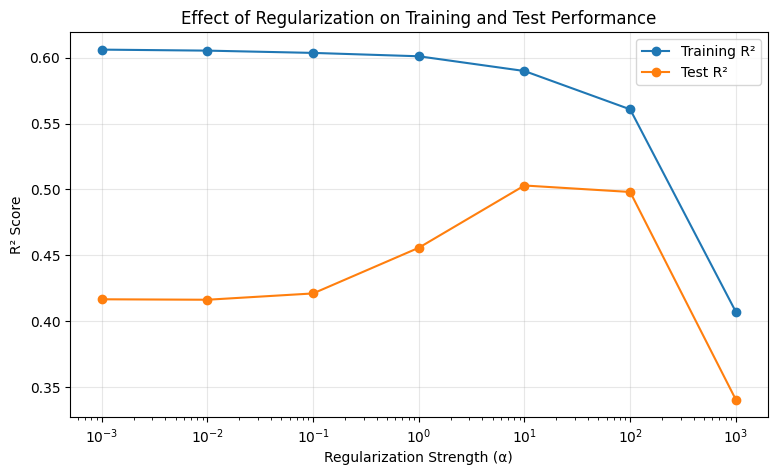

In [13]:
plt.figure(figsize=(9, 5))

plt.semilogx(
    results["Alpha"],
    results["Training R2"],
    marker="o",
    label="Training R²"
)

plt.semilogx(
    results["Alpha"],
    results["Test R2"],
    marker="o",
    label="Test R²"
)

plt.xlabel("Regularization Strength (α)")
plt.ylabel("R² Score")

plt.title(
    "Effect of Regularization on Training and Test Performance"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

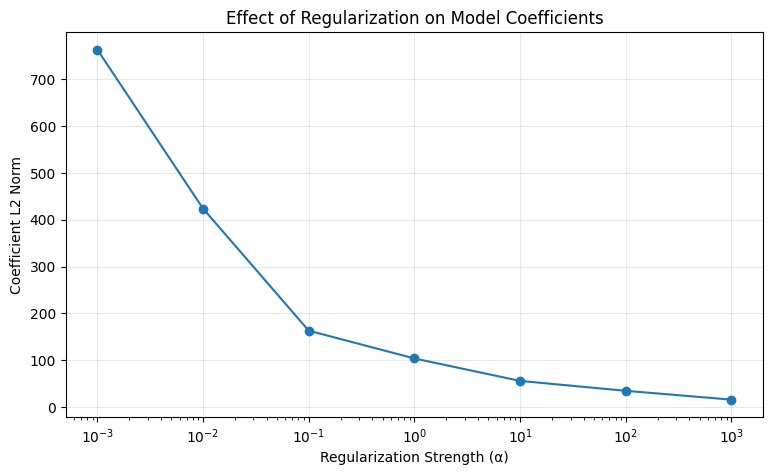

In [15]:
plt.figure(figsize=(9, 5))

plt.semilogx(
    results["Alpha"],
    results["Coefficient L2 Norm"],
    marker="o"
)

plt.xlabel("Regularization Strength (α)")
plt.ylabel("Coefficient L2 Norm")

plt.title(
    "Effect of Regularization on Model Coefficients"
)

plt.grid(True, alpha=0.3)
plt.show()

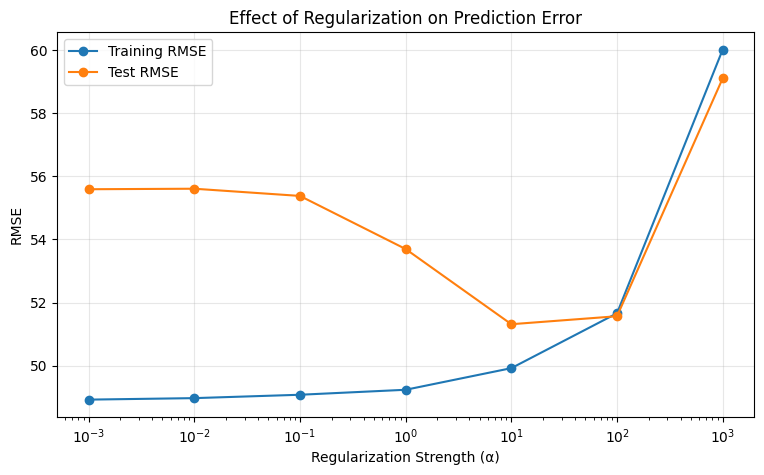

In [17]:
plt.figure(figsize=(9, 5))

plt.semilogx(
    results["Alpha"],
    results["Training RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.semilogx(
    results["Alpha"],
    results["Test RMSE"],
    marker="o",
    label="Test RMSE"
)

plt.xlabel("Regularization Strength (α)")
plt.ylabel("RMSE")

plt.title(
    "Effect of Regularization on Prediction Error"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
best_row = results.loc[
    results["Test R2"].idxmax()
]

print("Best test performance:")
print(best_row)

Best test performance:
Alpha                  10.000000
Training R2             0.589865
Test R2                 0.503014
Training RMSE          49.921392
Test RMSE              51.313828
Coefficient L2 Norm    56.246415
Name: 4, dtype: float64


In [20]:
results.to_csv(
    "team06_regularization_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
